# Diffraction limited profile of E-field

## Pupil Plane

The electric field in the pupil plane can be written as

$$
E_{\text{pupil}}(r) = E_S\,P(r)\,\Phi(r),
$$

where:

- $E_S$ is a constant amplitude,
- $P(r)$ is the **pupil function**, which describes the aperture (e.g. $P=1$ inside the aperture and $P=0$ outside),
- $\Phi(r)$ represents the phase of the incoming wavefront.

---

### Common Approximation

It might be tempting to approximate the image as a magnified version of the pupil, giving

$$
E(r) = E_S\,P\!\left(\frac{r}{\lambda F D_{\mathrm{tel}}}\right).
$$

Here, $P\!\left(\frac{r}{\lambda F D_{\mathrm{tel}}}\right)$ represents the pupil function evaluated at a scaled coordinate (not multiplication).

However, this corresponds to a **geometrical optics picture**, where the pupil is simply rescaled.

In reality, under diffraction-limited conditions, the image is formed by **wave interference**, and the correct description involves the Fourier transform of the pupil field.

### Key Point

- $P(r)$ → value of the pupil function at position $r$  
- $P\!\left(\frac{r}{\lambda F D_{\mathrm{tel}}}\right)$ → the same function evaluated at a **scaled coordinate**  

This is **function evaluation**, not multiplication.



## Image Plane: 
#### Diffraction-Limited Case

In the diffraction-limited case, we assume:

- no aberrations → $\Phi(r) = 1$  
- a uniform incoming wavefront  

so that

$$
E_{\text{pupil}}(r) = E_S\,P(r).
$$

---

#### How the Image is Formed

When this field passes through a lens or telescope and propagates to the focal plane, the waves originating from different points in the pupil interfere with each other.

This interference produces the image-plane electric field:

$$
E_{\text{image}}(r) \propto \mathcal{F}\{P(r)\}.
$$

That is, the image is **not a magnified copy of the pupil**, but rather the Fourier transform of the pupil field.

---



## Diffraction-Limited Imaging and the Airy Pattern

### Angular Resolution (Starting Point)

Diffraction is first described in terms of angle. For a circular aperture, the angular size of the central spot is

$$
\theta \sim 1.22 \frac{\lambda}{D_{\mathrm{tel}}}.
$$

This tells us the smallest angle over which two sources can be distinguished.

---

### From Angle to Physical Size in the Image

Think of a ray coming into the lens at a small angle $\theta$:

- It hits the focal plane at a distance $r$ from the centre  
- The focal length is $f$  

This forms a right triangle:

- opposite side = $r$  
- adjacent side = $f$  
- angle = $\theta$

To relate this to the image plane, we use the **small-angle approximation**:

$$
\tan\theta \approx \theta \quad (\text{for small } \theta).
$$

So that a ray at angle $\theta$ is mapped to a distance

$$
r \approx f\,\theta
$$

in the focal plane.

Substituting the diffraction limit:

$$
r \sim f \left(\frac{\lambda}{D_{\mathrm{tel}}}\right)
= \frac{\lambda f}{D_{\mathrm{tel}}}.
$$

So the size of the central diffraction spot (Airy disk) is set by

$$
r \sim \frac{\lambda f}{D_{\mathrm{tel}}} => \lambda F.
$$

---

### What Does This Mean Physically?

- Larger telescope ($D_{\mathrm{tel}} \uparrow$) → smaller spot  
- Longer wavelength ($\lambda \uparrow$) → larger spot  
- Larger focal length ($f \uparrow$) → larger image scale  

---

### Airy Pattern

For a circular aperture, the electric field in the image plane is

$$
E(r) \propto \frac{2J_1(s)}{s},
\qquad
s = \frac{\pi D_{\mathrm{tel}}\, r}{\lambda f},
$$

and the intensity is

$$
I(r) \propto \left(\frac{2J_1(s)}{s}\right)^2.
$$

Here, $r$ is the radial distance from the centre of the image.

---

### Important Concept

It might be tempting to think the image is just a scaled version of the pupil, for example:

$$
E_{\text{image}}(r) \propto P\!\left(\frac{r}{\lambda F}\right),
$$

where $F = f / D_{\mathrm{tel}}$ is the focal ratio.

Here, $P\!\left(\frac{r}{\lambda F}\right)$ represents the pupil function evaluated at a scaled coordinate (not multiplication).

However, this is **not correct**.

---

### Correct Fourier Optics Description

The correct relationship is that the image-plane field is given by the Fourier transform of the pupil field:

$$
E_{\text{image}}(r) \propto \hat{E}_{\text{pupil}}\!\left(\frac{r}{\lambda F D_{\mathrm{tel}}}\right).
$$

Since

$$
F = \frac{f}{D_{\mathrm{tel}}},
$$

we have

$$
\lambda F D_{\mathrm{tel}} = \lambda f,
$$

so this becomes

$$
E_{\text{image}}(r) \propto \hat{E}_{\text{pupil}}\!\left(\frac{r}{\lambda f}\right).
$$

---

### Interpretation

- The hat $\hat{E}_{\text{pupil}}$ denotes the **Fourier transform** of the pupil field  
- The argument $\frac{r}{\lambda f}$ is a **scaled coordinate**, not multiplication  
- The image is therefore **not a rescaled pupil**, but a diffraction pattern  

---

### Why This Matters

- $P(r)$ describes the aperture shape in the pupil plane  
- The image is formed by **wave interference**
- The correct operation is a **Fourier transform**
- The factor $\frac{r}{\lambda f}$ appears because the Fourier transform is evaluated at a diffraction-scaled coordinate  

---

### Key Takeaway

The telescope does not form a magnified image of the aperture.

Instead, it produces a diffraction pattern whose natural scale is set by

$$
\lambda f = \lambda F D_{\mathrm{tel}}.
$$

# The code

## Recall Single Mode step index fibre
From our previous notebook where we calculated the electric field properties of a single mode fibre, we derived the electric field profile as a function of the normalised amplitude vs the radial distance from the fibre centre. 

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi

In [2]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [3]:
# Approximate number of modes that the fibre can support using the V-number
M = V**2 / 4
print(f"Approximate number of modes that the fibre can support: {M:.2f}")

Approximate number of modes that the fibre can support: 1.10


In [4]:
# Given the X and Y roots for the LP01 mode from previous calculations
X_root = 1.5590595758091075
Y_root = 1.3985078062014993

# Calculate the electric field distribution for the fundamental mode (LP01) in a step-index fibre
# Step 1- Create the radius array for plotting the electric field distribution
rho = np.linspace(0, 100, 5000) # From 0 to 100 times the core radius


In [5]:
def calculate_electric_field(rho, X_root, Y_root):
    """ 
    Define a function to calculate the electric field distribution across the fibre 
    cross-section based on the roots found from the Bessel function equations. This function 
    will compute the electric field in both the core and cladding regions, normalise it, and 
    return both the normalised electric field and its intensity profile. 

    X_root: The root of the equation for the core region, which determines the behaviour of the electric field within the core.
    Y_root: The root of the equation for the cladding region, which determines the behaviour of the electric field in the cladding.
    rho: The normalised radius array (r/a) across which we want to calculate the electric field distribution.

    """

    # Step 2 - Create an array of zeros with the same shape as rho to store the electric field values
    E = np.zeros_like(rho)

    # Step 3 - Set the condition as the boundary between core and cladding, this helps to create a piecewise function for the electric field distribution
    core = rho <= 1
    cladding = rho > 1

    # Step 4 - Compute the electric field in the core region (rho <= 1) using the ordinary Bessel function J0.
    # E[core] uses conditional (boolean) assignment directly: values are assigned only where the condition is satisfied, allowing us to implement the piecewise solution of the wave equation without using loops.
    # Physically, this corresponds to applying the core solution E(rho) = J0(X*rho) only inside the fibre core.

    E[core] = jv(0, X_root * rho[core]) # Setting A = 1, multiplied by te Bessel function of zeroth order and ratio rho inside the core

    # Step 5 - Set the matching factor at the boundary (rho=1) as J0(X) / K0(Y), this makes the cladding field connect smoothly
    match_factor = jv(0,X_root) / kv(0,Y_root) 

    # Step 6 - Compute the electric field in the cladding region (rho > 1) using the modified Bessel function K0, multiplied by the matching factor to ensure continuity at the boundary
    E[cladding] = match_factor * kv(0, Y_root * rho[cladding])

    # Step 7 - Normalise the electric field distribution so that the maximum value is 1, this allows us to compare the relative field strength across the fibre cross-section
    E_norm = E / np.max(abs(E)) 

    # Step 8 - We also compute the intensity profile of the electric field, such that I represents the intensity profile and E represents the field amplitude. 
    I = np.abs(E_norm)**2

    return E_norm, I # note they are in normalised units

In [6]:
# Calculate electric field and intensity profiles using the function 
E_smf, I_smf = calculate_electric_field(rho, X_root, Y_root)
print(E_smf.shape, I_smf.shape)

(5000,) (5000,)


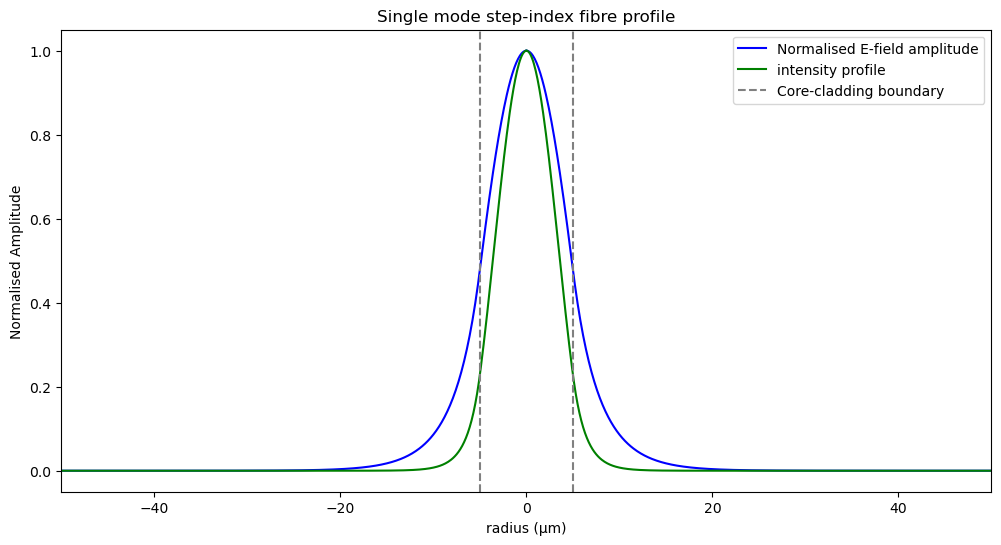

In [7]:
# Plot the normalised electric field distribution and the intensity profile
plt.figure(figsize=(12, 6))
plt.plot(rho * a * 1e6, E_smf, label = 'Normalised E-field amplitude', color='blue')
plt.plot(-rho * a * 1e6, E_smf, color='blue')
plt.plot(rho * a * 1e6, I_smf, label = 'intensity profile', color='green')
plt.plot(-rho * a * 1e6, I_smf, color='green')
plt.axvline(a * 1e6, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.axvline(-a * 1e6, color = 'gray', linestyle='--')
plt.title("Single mode step-index fibre profile")
plt.xlabel('radius (µm)')
plt.ylabel('Normalised Amplitude')
plt.legend()

plt.xlim(-50,50)

plt.show()

## Airy Pattern for the Diffraction Limit

For a circular aperture, the electric field in the image plane is

$$
E(r) \propto \frac{2J_1(s)}{s},
\qquad
s = \frac{\pi D_{\mathrm{tel}}\, r}{\lambda f},
$$

and the intensity is

$$
I(r) \propto \left(\frac{2J_1(s)}{s}\right)^2.
$$

Here, $r$ is the radial distance from the centre of the image.

---

The Airy pattern arises because the image is formed by the **Fourier transform of the pupil field**. For a circular aperture **(a uniform disk)**, this naturally produces a **Bessel function**, giving a **bright central peak surrounded by rings**. This is why the image is not a flat disk, but a pattern with a bright central spot and rings.

Physically, each point in the pupil emits waves that interfere in the focal plane:

- at $r=0$ → constructive interference (bright central spot)  
- away from the centre → alternating constructive and destructive interference (rings)  

The variable $s$ is a **dimensionless coordinate**, meaning it has no units. It is defined by comparing the physical distance $r$ in the image plane to the characteristic diffraction scale

$$
r_0 = \frac{\lambda f}{D_{\mathrm{tel}}}.
$$

So we define

$$
s = \frac{r}{r_0} = \frac{r}{\lambda f / D_{\mathrm{tel}}}.
$$

---

### Physical Interpretation

- $r$ → actual distance in the image plane (e.g. metres or microns)  
- $r_0 = \lambda f / D_{\mathrm{tel}}$ → size of the diffraction-limited spot  

So $s$ tells us:

- $s = 1$ → one diffraction spot radius from the centre  
- $s < 1$ → inside the central bright region  
- $s > 1$ → outside, where rings begin to appear  

---

### Why This Is Useful

Using $s$ removes units and lets us describe the Airy pattern in a universal way, independent of the specific telescope or wavelength.

This Airy pattern represents the **diffraction-limited electric field**, which will be used as the input field when modelling coupling into a single-mode fibre.

In [37]:
# Define a radial grid
r = rho * a # keep in metres

# Let's assume the focal ratio f/# is 49.9, where the focal length is 399m and D=8.0m (effectively)
F = 49.9

print(f"Radius range (r) in microns: {r[0] * 1e6:.2f} µm to {r[-1] * 1e6:.2f} µm")
print(f"Focal ratio (f/#) ~ {F:.4f}")

Radius range (r) in microns: 0.00 µm to 500.00 µm
Focal ratio (f/#) ~ 49.9000


Using information from ESO website: https://www.eso.org/sci/facilities/paranal/telescopes/ut/m1unit.html#:~:text=Mounting%20of%20the%20axial%20interfaces,down%20to%20sub%2Dmicron%20accuracy. 


In [ ]:
# Define the diffraction limited E-field

# Not sure how big the obstruction is, assume it's 11.1 meters in diameter 
D_M1 = 8.0 # Diameter of the primary mirror in meters
D_obstruction = 1.0 # Diameter of the central obstruction in meters
alpha = D_obstruction / D_M1 # Ratio of the central obstruction to the primary mirror diameter

# Assume E_S = 1m exactly for the amplitude of the E-field
E_S = 1

def coude_diffraction_limited_E_field(r, lam0, F, alpha, E_S):

    """
    Functino for calculating the E-field at diffraction limited E_field, specifically for
    the Coude focus (or a focus that has a long focal length resulting in high magnification)

    
    """

    s = np.pi * r / (lam0 * F) # Normalised radial coordinate for the diffraction pattern

    # Use safe division so the s=0 limit is finite (2*J1(x)/x -> 1 as x->0)
    airy_term = np.divide(2 * j1(s), s, out=np.ones_like(s), where=s != 0)
    obstruction_term = np.divide(2 * j1(alpha * s), alpha * s, out=np.ones_like(s), where=(alpha * s) != 0)

    # The electric field of image found from the diffraction pattern of the telescope aperture, modified by the 
    # central obstruction, multiplied by the fibre mode field distribution to get the resulting image field 
    # distribution at the fibre input. Note: zero division at centre is artificially set to 1 
    E_image = E_S * (airy_term - alpha**2 * obstruction_term)

    # Intensity of the incoming beam forming an image at the fibre input 
    I_image = np.abs(E_image)**2

    return E_image, I_image

In [10]:
E_image, I_image = coude_diffraction_limited_E_field(r, lam0, F, alpha, E_S)

In [11]:
alpha

0.125

In [12]:
E_image

array([0.984375  , 0.9843728 , 0.98436619, ..., 0.01071294, 0.01072535,
       0.01073747], shape=(5000,))

In [13]:
# 1.22*lam0 * F

In [14]:
lam0

1.5e-06

In [15]:
(1.22*lam0 * F)* 1e6

91.31700000000001

In [16]:
F

49.9

In [17]:
# The angular resolution of the telescope, which is the diffraction limit
theta = (1.22 * lam0 / D_M1) * (180 / np.pi) * 3600 # convert to arcseconds
print(f"Angular resolution (diffraction limit) of the telescope: {theta:.4f} arcseconds")

Angular resolution (diffraction limit) of the telescope: 0.0472 arcseconds


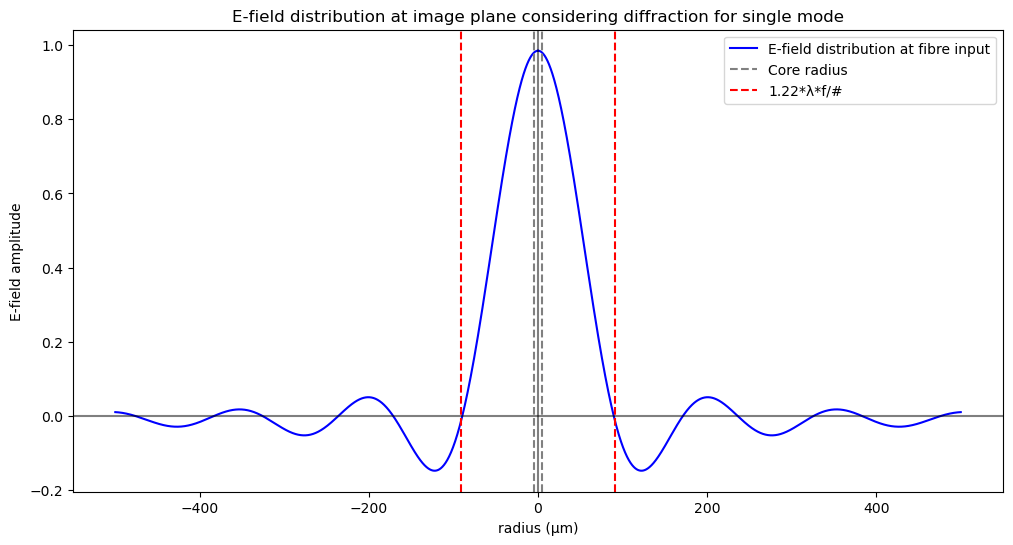

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(r * 1e6, E_image, label = 'E-field distribution at fibre input', color='blue')
plt.plot(-r * 1e6, E_image, color='blue') # Plot the negative radius to show the symmetry of the diffraction pattern
plt.axhline(0, color='black', alpha=0.5) # Add a horizontal line at y=0 for reference
plt.axvline(0, color='black', alpha=0.5) # Add a vertical line at x=0 for reference
plt.axvline(a * 1e6, color = 'gray', linestyle='--', label='Core radius')
plt.axvline((-a) * 1e6, color = 'gray', linestyle='--')
plt.axvline((1.22*lam0 * F)* 1e6, color = 'red', linestyle='--', label='1.22*λ*f/#')
plt.axvline((-1.22*lam0 * F)* 1e6, color = 'red', linestyle='--')
plt.title("E-field distribution at image plane considering diffraction for single mode")
plt.xlabel('radius (µm)')
plt.ylabel('E-field amplitude')
plt.legend()
plt.show()

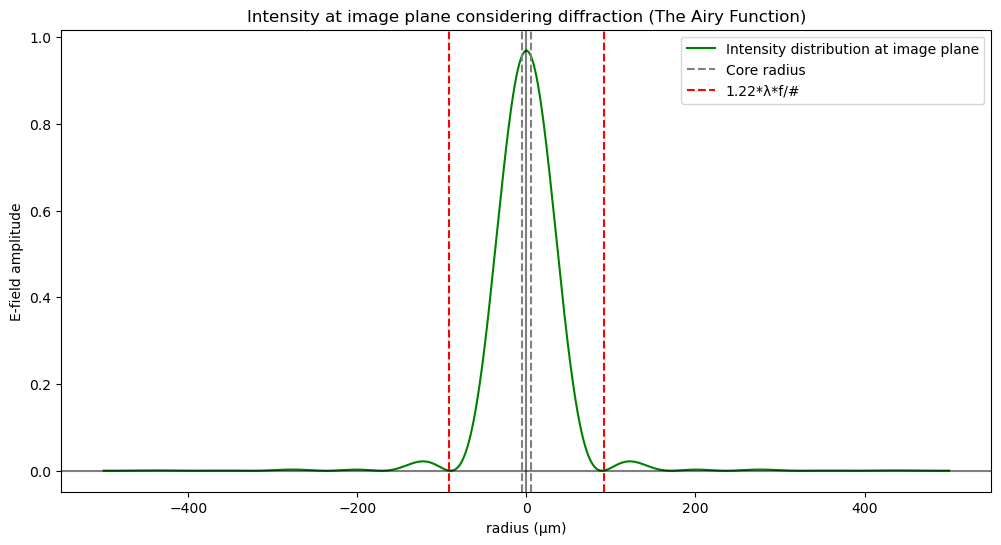

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(r * 1e6, I_image, label = 'Intensity distribution at image plane', color='green')
plt.plot(-r * 1e6, I_image, color='green') # Plot the negative radius to show the symmetry of the diffraction pattern
plt.axhline(0, color='black', alpha=0.5) # Add a horizontal line at y=0 for reference
plt.axvline(0, color='black', alpha=0.5) # Add a vertical line at x=0 for reference
plt.axvline(a * 1e6, color = 'gray', linestyle='--', label='Core radius')
plt.axvline((-a) * 1e6, color = 'gray', linestyle='--')
plt.axvline((1.22*lam0 * F)* 1e6, color = 'red', linestyle='--', label='1.22*λ*f/#')
plt.axvline((-1.22*lam0 * F)* 1e6, color = 'red', linestyle='--')
plt.title("Intensity at image plane considering diffraction (The Airy Function)")
plt.xlabel('radius (µm)')
plt.ylabel('E-field amplitude')
plt.legend()
plt.show()

Since we assumed a numerical aperture of $\mathrm{NA} \approx 0.1$, which corresponds to a focal ratio of approximately $F \approx 5$ using the relation $\mathrm{NA} \approx 1/(2F)$.

At the VLT coudé focus, the beam has a much slower focal ratio of $F \approx 49.9$. To match the fibre acceptance, re-imaging optics are used to convert this beam to the desired injection focal ratio.

The required magnification (M = output size / input size) is therefore given by the ratio of the focal ratios,

$$
M = \frac{F_{\mathrm{inj}}}{F_{\mathrm{coud\acute{e}}}} = \frac{5}{49.9} \approx 0.10,
$$

corresponding to a demagnification of approximately 10×.

In [20]:
# Radius of airy disk at the first minimum after demagnification
r_airy = 1.22 * lam0 * F
print(f"Radius of airy disk at the first minimum: {r_airy} meters")

Magnification = 5 / 49.9
r_airy_demag = (1.22*lam0 * F) * Magnification

print(f"Radius of airy disk at the first minimum after demagnification: {r_airy_demag} meters")

Radius of airy disk at the first minimum: 9.131700000000001e-05 meters
Radius of airy disk at the first minimum after demagnification: 9.15e-06 meters


But in reality we use $\lambda F$ the diffracion scale as the size of the image, and we use this value when we are estimating the coupling and matching fibre size. 

In [21]:
r_image_demag = (lam0 * F) * Magnification

print(f"Radius of airy disk at the first minimum after demagnification: {r_image_demag} meters")

Radius of airy disk at the first minimum after demagnification: 7.5e-06 meters


Remake the electric field profile of the demagnified image on the same r grid:

In [ ]:
def demagnified_diffraction_limited_E_field(r, lam0, F, alpha, E_S, Magnification):
    """
    r: the radius array created, representing distance vector in the ribre radius
    
    lam0: wavelength of the light in air

    F: focal ratio F=f/D at the focus or after re-imager

    alpha: the ratio of central obstration to primary mirror diameter

    E_S: amplitude of the E-field of image normalised (assumed) to equal to 1 here

    Magnification: different to the magnification measurement between image at the telescope 
    and focus, the Magnification here refers to the required scale of "magnification" or inverted 
    demagnification required for the re-imaging optics

    """

    s_demag = np.pi * r / (lam0 * F * Magnification) # Normalised radial coordinate for the diffraction pattern after demagnification

    # Use safe division so the s=0 sample does not produce NaN
    airy_term_demag = np.divide(2 * j1(s_demag), s_demag, out=np.ones_like(s_demag), where=s_demag != 0)
    obstruction_term_demag = np.divide(2 * j1(alpha * s_demag), alpha * s_demag,
        out=np.ones_like(s_demag),
        where=(alpha * s_demag) != 0,
    )

    # The electric field of image found from the diffraction pattern of the telescope aperture, modified by the 
    # central obstruction, multiplied by the fibre mode field distribution to get the resulting image field distribution at the fibre input.
    E_image_demag = E_S * (airy_term_demag - alpha**2 * obstruction_term_demag)

    # Intensity of the incoming beam forming an image at the fibre input 
    I_image_demag = np.abs(E_image_demag)**2

    return E_image_demag, I_image_demag

In [23]:
E_image_demag, I_image_demag = demagnified_diffraction_limited_E_field(r, lam0, F, alpha, E_S, Magnification)
print(E_image_demag.shape, I_image_demag.shape)

(5000,) (5000,)


In [48]:
I_image_demag

array([9.68994141e-01, 9.68562358e-01, 9.67267965e-01, ...,
       1.99862983e-07, 2.05196388e-07, 2.09789083e-07], shape=(5000,))

In [49]:
E_image_demag

array([9.84375000e-01, 9.84155657e-01, 9.83497822e-01, ...,
       4.47060379e-04, 4.52986080e-04, 4.58027383e-04], shape=(5000,))

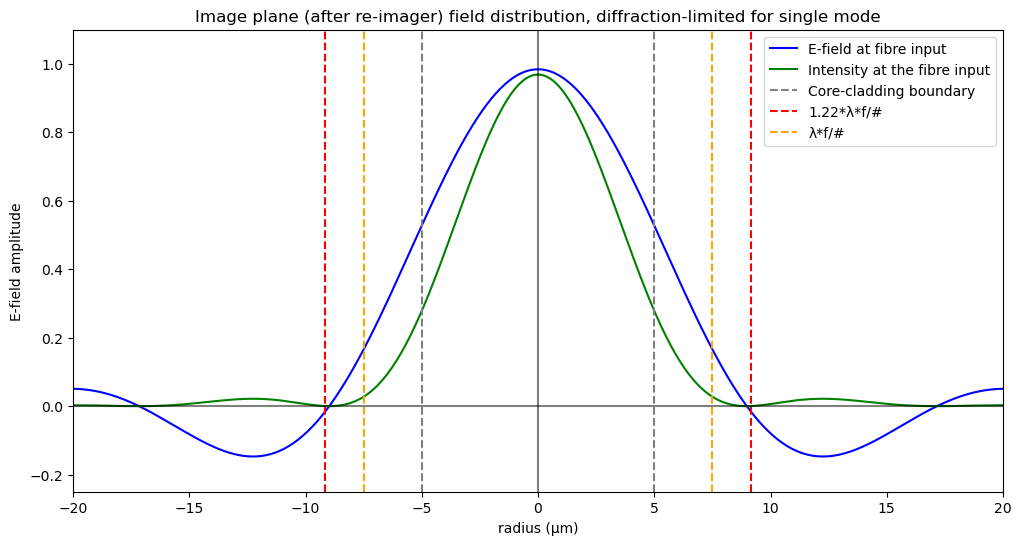

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(r * 1e6, E_image_demag, label = 'E-field at fibre input', color='blue')
plt.plot(-r * 1e6, E_image_demag, color='blue') # Plot the negative radius to show the symmetry of the diffraction pattern
plt.plot(r * 1e6, I_image_demag, label = 'Intensity at the fibre input', color='green')
plt.plot(-r * 1e6, I_image_demag, color='green')

plt.axhline(0, color='black', alpha=0.5) # Add a horizontal line at y=0 for reference
plt.axvline(0, color='black', alpha=0.5) # Add a vertical line at x=0 for reference
plt.axvline(a * 1e6, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.axvline((-a) * 1e6, color = 'gray', linestyle='--')
plt.axvline(r_airy_demag * 1e6, color = 'red', linestyle='--', label='1.22*λ*f/#')
plt.axvline((-r_airy_demag) * 1e6, color = 'red', linestyle='--')
plt.axvline(r_image_demag * 1e6, color = 'orange', linestyle='--', label='λ*f/#')
plt.axvline((-r_image_demag) * 1e6, color = 'orange', linestyle='--')

plt.title("Image plane (after re-imager) field distribution, diffraction-limited for single mode")
plt.xlabel('radius (µm)')
plt.ylabel('E-field amplitude')
plt.legend()
plt.xlim(-20,20)
plt.ylim(-0.25,1.1)
plt.show()

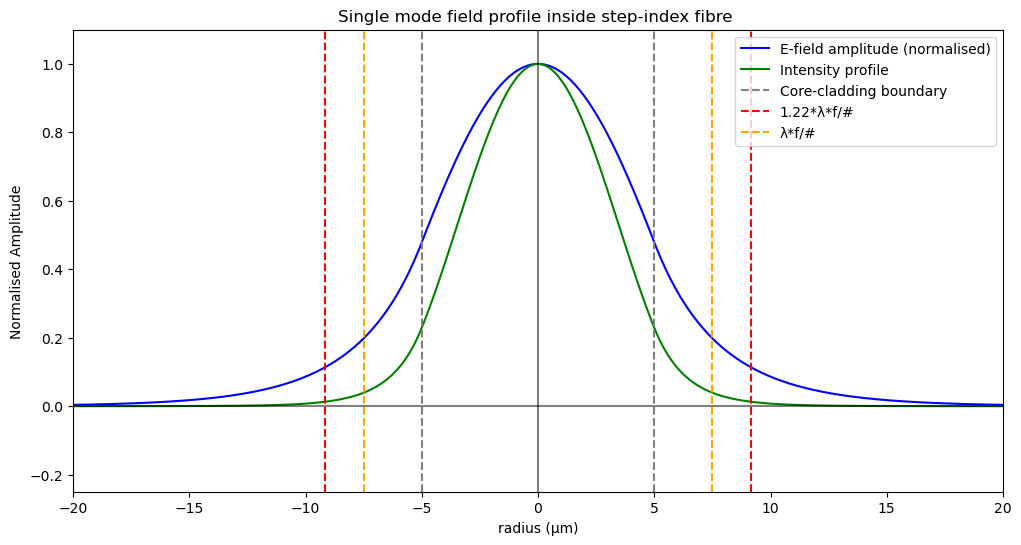

In [47]:
# Plot the normalised electric field distribution and the intensity profile
plt.figure(figsize=(12, 6))
plt.plot(rho * a * 1e6, E_smf, label = 'E-field amplitude (normalised)', color='blue')
plt.plot(-rho * a * 1e6, E_smf, color='blue')
plt.plot(rho * a * 1e6, I_smf, label = 'Intensity profile', color='green')
plt.plot(-rho * a * 1e6, I_smf, color='green')

plt.axvline(a * 1e6, color = 'gray', linestyle='--', label='Core-cladding boundary')
plt.axvline(-a * 1e6, color = 'gray', linestyle='--')

plt.axhline(0, color='black', alpha=0.5) # Add a horizontal line at y=0 for reference
plt.axvline(0, color='black', alpha=0.5) # Add a vertical line at x=0 for reference
plt.axvline(r_airy_demag * 1e6, color = 'red', linestyle='--', label='1.22*λ*f/#')
plt.axvline((-r_airy_demag) * 1e6, color = 'red', linestyle='--')
plt.axvline(r_image_demag * 1e6, color = 'orange', linestyle='--', label='λ*f/#')
plt.axvline((-r_image_demag) * 1e6, color = 'orange', linestyle='--')

plt.title("Single mode field profile inside step-index fibre ")
plt.xlabel('radius (µm)')
plt.ylabel('Normalised Amplitude')
plt.legend()

plt.xlim(-20,20)
plt.ylim(-0.25,1.1)
plt.show()

# Find the efficiency of the electric field between the image and fibre

We use the overlap integral to calculate the coupling efficiency. In general, this is written as

$$
\eta =
\frac{
\left|
\iint E_0(x,y)\,E_m^*(x,y)\,dx\,dy
\right|^2
}{
\left(\iint |E_0(x,y)|^2\,dx\,dy\right)
\left(\iint |E_m(x,y)|^2\,dx\,dy\right)
}.
$$

For a circularly symmetric system, the electric fields depend only on the radial coordinate $r$, so we change from Cartesian coordinates to polar coordinates using

$$
dx\,dy = r\,dr\,d\phi.
$$

The overlap integral then becomes

$$
\eta =
\frac{
\left|
\int_0^{2\pi}\int_0^\infty E_0(r)\,E_m^*(r)\,r\,dr\,d\phi
\right|^2
}{
\left(\int_0^{2\pi}\int_0^\infty |E_0(r)|^2\,r\,dr\,d\phi\right)
\left(\int_0^{2\pi}\int_0^\infty |E_m(r)|^2\,r\,dr\,d\phi\right)
}.
$$

Since the fields are independent of angle $\phi$, the angular integral simply gives a factor of $2\pi$, so this simplifies to

$$
\eta =
\frac{
\left|
\int_0^\infty E_0(r)\,E_m^*(r)\,2\pi r\,dr
\right|^2
}{
\left(\int_0^\infty |E_0(r)|^2\,2\pi r\,dr\right)
\left(\int_0^\infty |E_m(r)|^2\,2\pi r\,dr\right)
}.
$$

Therefore, for a radially symmetric diffraction-limited image field and a radially symmetric single-mode fibre field, the 2D overlap integral reduces to a 1D radial integral weighted by $2\pi r$. 

Note that the overlap integral formally includes the complex conjugate of the fibre mode field, as it is defined as an inner product. In the present case, the electric fields are real-valued, so taking the complex conjugate does not change the result, but it must be retained for generality when phase variations are present.


In [26]:
# np.trapezoid?
# Integrate along the given axis using the composite trapezoidal rule.
# The trapezoidal rule is a numerical integration method that approximates the area under a curve by dividing 
# it into trapezoids, which can provide a more accurate estimate than simple rectangular methods, especially 
# for smooth functions.

In [ ]:
# The entire radial range
def coupling_efficiency(E_image_demag, E_smf):
    """
    Input: 
    E_image_demag: electric field of demagnified image
    E_smf: electric field of single mode fibre

    Output: 
    numerator = |∫ E_image_demag * conj(E_smf) * 2πr dr|^2
    denominator = ∫ |E_smf|^2 * 2πr dr * ∫ |E_image_demag|^2 * 2πr dr
    efficiency eta: we integrate from infinitely large radius to the centre (but here 
    instead of infinity we use the finite range of r that we have where largest r must be larger
    than cladding radius to capture the Evanescent field distribution)
    
    """
    numerator = np.abs(np.trapezoid(E_image_demag * np.conjugate(E_smf) * 2*np.pi*r, x=r))**2
    denominator = np.trapezoid(np.abs(E_smf)**2 * 2*np.pi*r, x=r) * np.trapezoid(np.abs(E_image_demag)**2 * 2*np.pi*r, x=r)
    # Calculate efficiency:
    eta = numerator / denominator

    return eta, numerator, denominator

In [36]:
eta, numerator, denominator = coupling_efficiency(E_image_demag, E_smf)
print(f"Numerator: {numerator:.6e}")
print(f"Denominator: {denominator:.6e}")
print(f"Coupling efficiency (η) = {eta:.6f}")

Numerator: 2.836863e-21
Denominator: 3.956726e-21
Coupling efficiency (η) = 0.716972


### Quick test: limiting cladding radius to 50 $\mu m$

In [61]:
a

5e-06

In [70]:
rho_test50 = np.linspace(0,10,5000)
r_test50 = rho_test50 * a

In [71]:
Magnification

0.10020040080160321

In [72]:
E_image_test50, I_image_test50 = demagnified_diffraction_limited_E_field(r_test50, lam0, F, alpha, E_S, Magnification)
E_smf_test50, I_smf_test50 = calculate_electric_field(rho_test50, X_root, Y_root)

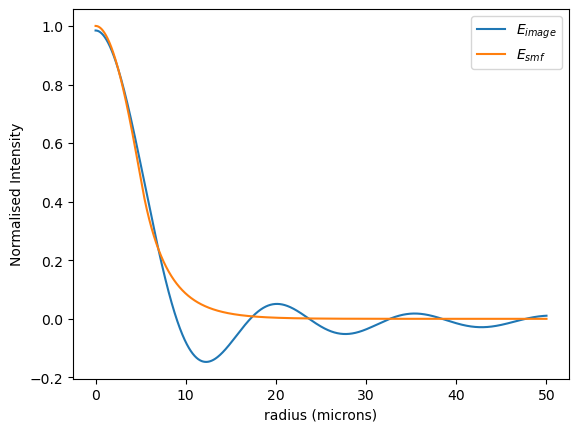

In [78]:
plt.plot(r_test50 *1e6, E_image_test50, label='$E_{image}$')
plt.plot(r_test50 *1e6, E_smf_test50, label='$E_{smf}$')
plt.xlabel("radius (microns)")
plt.ylabel("Normalised Intensity")
plt.legend()

In [79]:
# It appears that the efficiency is higher if our cladding is limited to 50µm rather than 500µm
eta_test, numerator_test, denominator_test = coupling_efficiency(E_image_test50, E_smf_test50)
eta_test

np.float64(0.7397423339714665)

In [81]:
rho_test100 = np.linspace(0,100,5000)
r_test100 = rho_test100 * a
E_image_test100, I_image_test100 = demagnified_diffraction_limited_E_field(r_test100, lam0, F, alpha, E_S, Magnification)
E_smf_test100, I_smf_test100 = calculate_electric_field(rho_test100, X_root, Y_root)
eta_test100, numerator_test100, denominator_test100 = coupling_efficiency(E_image_test100, E_smf_test100)
eta_test100

np.float64(0.7169724284682676)